In [1]:
import pandas as pd
import re
import os
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix

In [2]:
yelp_train_df = pd.read_csv("C:/Users/neerajdattu.dudam/USD/Spring 2025/project/final_data/yelp/train.csv")
yelp_dev_df = pd.read_csv("C:/Users/neerajdattu.dudam/USD/Spring 2025/project/final_data/yelp/dev.csv")
yelp_test_df = pd.read_csv("C:/Users/neerajdattu.dudam/USD/Spring 2025/project/final_data/yelp/test.csv")

dynabench_train_df = pd.read_csv("C:/Users/neerajdattu.dudam/USD/Spring 2025/project/final_data/dynabench/train.csv")
dynabench_dev_df = pd.read_csv("C:/Users/neerajdattu.dudam/USD/Spring 2025/project/final_data/dynabench/dev.csv")
dynabench_test_df = pd.read_csv("C:/Users/neerajdattu.dudam/USD/Spring 2025/project/final_data/dynabench/test.csv")

yelp_dynabench_2500_train_df = pd.read_csv("C:/Users/neerajdattu.dudam/USD/Spring 2025/project/final_data/yelp_dynabench_2500/train.csv")
yelp_dynabench_2500_dev_df = pd.read_csv("C:/Users/neerajdattu.dudam/USD/Spring 2025/project/final_data/yelp_dynabench_2500/dev.csv")
yelp_dynabench_2500_test_df = pd.read_csv("C:/Users/neerajdattu.dudam/USD/Spring 2025/project/final_data/yelp_dynabench_2500/test.csv")

In [3]:
yelp_train_df = pd.concat([yelp_train_df, yelp_dev_df])
dynabench_train_df = pd.concat([dynabench_train_df, dynabench_dev_df])
yelp_dynabench_2500_train_df = pd.concat([yelp_dynabench_2500_train_df, yelp_dynabench_2500_dev_df])

In [4]:
dataFrames = [[yelp_train_df, yelp_test_df], [dynabench_train_df, dynabench_test_df], [yelp_dynabench_2500_train_df, yelp_dynabench_2500_test_df]]

# Mapping function
label_mapping = {'positive': 1, 'neutral': 0, 'negative': -1}

# Iterate over each DataFrame name
for df_train, df_test in dataFrames:
    
    # Apply the mapping to the 'label' column
    df_train['label'] = df_train['label'].map(label_mapping)
    df_test['label'] = df_test['label'].map(label_mapping)  

# Example to check the changes
print(yelp_train_df.head())

                                                text  label
0  I haven't been on an AA flight that hasn't bee...     -1
1  Went differently because of his reviews and pr...      0
2         So if you see this dog, AVOID AVOID AVOID!     -1
3                 De-li-cious tacos for $9 straight.      1
4          He them saw me, and asked what was wrong.      0


In [5]:
def preprocess_with_stemming(data):
    # Initialize stemmer
    stemmer = PorterStemmer()
    
    # Define stop words
    stop_words = set(stopwords.words('english'))
    
    # Preprocessing function
    def preprocess_text(text):
        # Remove non-alphabetic characters
        text = re.sub(r'[^a-zA-Z\s]', '', text)
        # Replace multiple spaces with a single space
        text = re.sub(r'\s+', ' ', text).strip()
        # Convert to lowercase
        text = text.lower()
        # Tokenize
        words = word_tokenize(text)
        # Remove stop words and apply stemming
        words = [stemmer.stem(word) for word in words if word not in stop_words]
        return ' '.join(words)
    
    # Apply preprocessing to each row in the dataframe
    data['text'] = data['text'].apply(preprocess_text)
    
    return data

In [6]:
for df_train, df_test in dataFrames:
    # Apply the preprocessing function
    df_train = preprocess_with_stemming(df_train)
    df_test = preprocess_with_stemming(df_test)

# Example to check the changes
print(yelp_train_df.head())

                                     text  label
0     havent aa flight hasnt delay cancel     -1
1  went differ review proxim ann centenni      0
2               see dog avoid avoid avoid     -1
3                    delici taco straight      1
4                           saw ask wrong      0


In [7]:
# Function to get the sentiment label
def get_sentiment_label(train_df, test_df):
    # Prepare the data
    X_train = train_df['text']
    y_train = train_df['label']
    X_test = test_df['text']
    
    # Create a pipeline with CountVectorizer and MultinomialNB
    model = make_pipeline(CountVectorizer(), MultinomialNB())    
    
    # Train the model
    model.fit(X_train, y_train)
    
    # Predict the labels
    return model.predict(X_test)    

prediction = []

# Apply the function to each dataframe
for df_train, df_test in dataFrames:
    y_pred = get_sentiment_label(df_train, df_test)
    
    prediction.append([df_test['label'], y_pred])


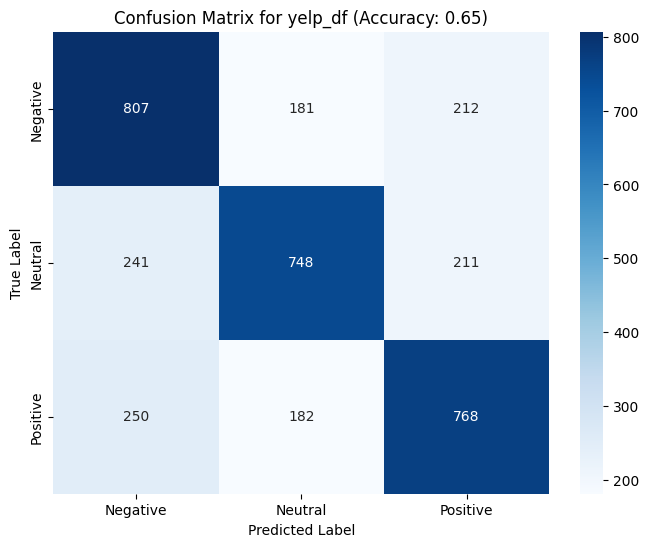

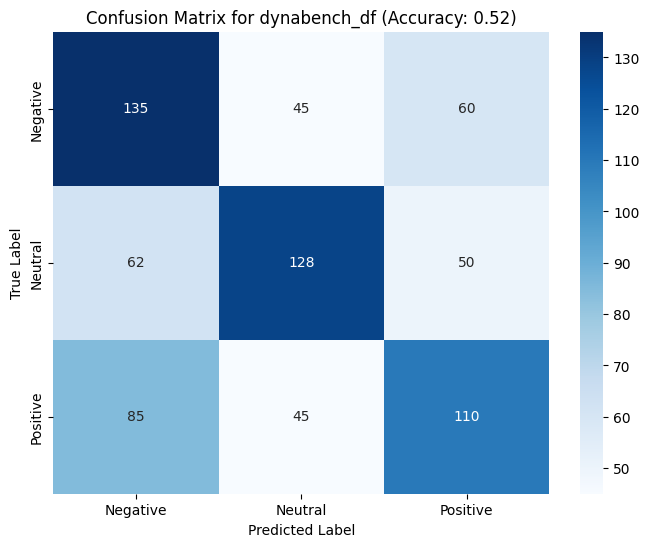

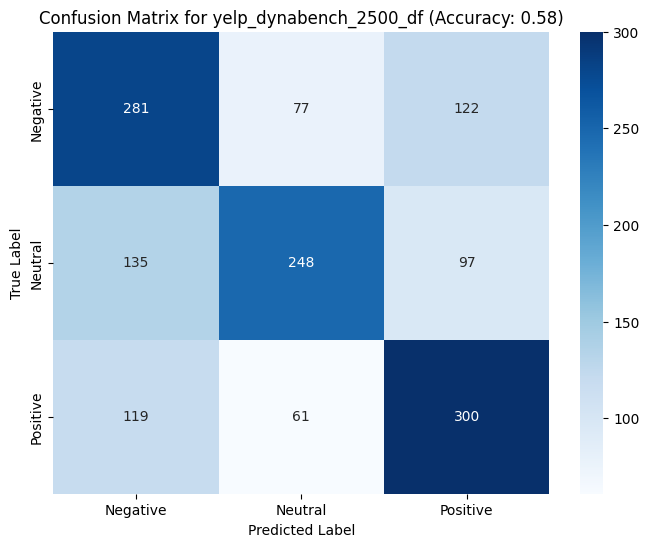

In [8]:
# Function to calculate accuracy and plot confusion matrix
def evaluate_sentiment(df_y_test, df_y_pred, df_name):
    accuracy = accuracy_score(df_y_test, df_y_pred)
    conf_matrix = confusion_matrix(df_y_test, df_y_pred)
    
    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Neutral', 'Positive'], yticklabels=['Negative', 'Neutral', 'Positive'])
    plt.title(f'Confusion Matrix for {df_name} (Accuracy: {accuracy:.2f})')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()
    
# Evaluate each prediction
for df_name, (df_y_test, df_y_pred) in zip(['yelp_df', 'dynabench_df', 'yelp_dynabench_2500_df'], prediction):
    evaluate_sentiment(df_y_test, df_y_pred, df_name)